# Telco Customer Churn & Retention Analysis

## Data Preparation

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
# checking the shape of the dataset
df.shape

(7043, 21)

In [3]:
# checking dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# checking for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [6]:
# checking summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# converting total charges from str to float data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [8]:
# checking again for missing values
df["TotalCharges"].isna().sum()

np.int64(11)

In [9]:
# converting the SeniorCitizen column from 1/0 to Yes/No for readability
df["SeniorCitizen"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})
df["SeniorCitizen"]

0        No
1        No
2        No
3        No
4        No
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: SeniorCitizen, Length: 7043, dtype: str

In [10]:
# checking value counts of the SeniorCitizen column
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

In [11]:
# verifying changes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#### Data Type Corrections
Two data-type changes were made during data preparation:

SeniorCitizen: Converted from integer values (0/1) to categorical labels (No/Yes) to improve readability.
TotalCharges: Converted from string to numeric (float64) using pd.to_numeric(). The conversion resulted in 11 missing values because some original entries could not be converted to numbers.

No other data-type changes were required.

## Churn Analysis

### Overall Churn

In [12]:
# finding total customers
total_customers = len(df)
print(f"Total Customers: {total_customers}")

Total Customers: 7043


In [13]:
# finding churned customers
churned_customers = (df["Churn"] == "Yes").sum()
print(f"Churned Customers: {churned_customers}")

Churned Customers: 1869


In [14]:
# finding retained customers
retained_customers = (df["Churn"] == "No").sum()
print(f"Retained Customers: {retained_customers}")

Retained Customers: 5174


In [15]:
# finding churn rate
churn_rate = (churned_customers/total_customers) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


**Interpretation:** The dataset contains 7,043 customers, of whom 1,869 have churned and 5,174 have been retained. This results in an overall churn rate of 26.54%, meaning roughly one in four customers has left the company.

### Churn by Contract Type

In [16]:
# checking value counts for the Contract column
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [17]:
# grouping churn counts by Contract
df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [18]:
# calculating churn rates of each contract type
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)
contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

In [19]:
# contract type with highest churn rate
print(f"Contract Type with Highest Churn Rate: {contract_churn.idxmax()}")
print(f"Churn Rate: {contract_churn.max():.2f}")

Contract Type with Highest Churn Rate: Month-to-month
Churn Rate: 42.71


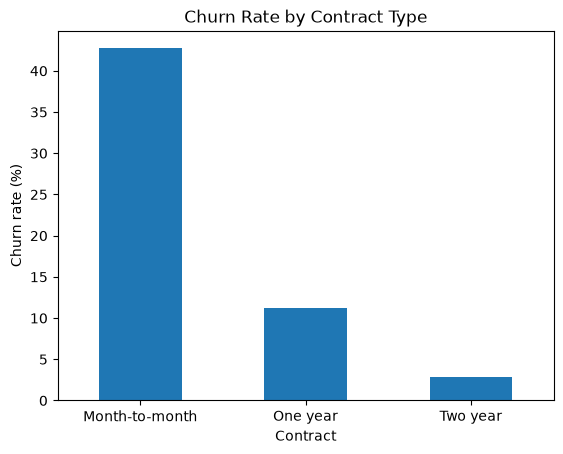

In [20]:
# building the chart
contract_churn.plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% for one-year contracts and only 2.83% for two-year contracts. This shows a substantial difference in churn across contract types, with customers on shorter contracts being much more likely to leave.

### Churn by Tenure Group

In [21]:
# checking summary statistics for tenure
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [22]:
# creating tenure groups using bins
bins = [0, 12, 24, 48, float("inf")]
labels = ["0–12", "13–24", "25–48", "49+"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

In [23]:
# checking the number of customers in each tenure group
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0–12     2186
13–24    1024
25–48    1594
49+      2239
Name: count, dtype: int64

In [24]:
# calculating churn rate for each tenure group
tenure_churn = df.groupby("TenureGroup", observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)
tenure_churn

TenureGroup
0–12     47.438243
13–24    28.710938
25–48    20.388959
49+       9.513176
Name: Churn, dtype: float64

In [25]:
# highest-risk tenure group with its churn rate
print(f"Tenure Group with Highest Churn Rate: {tenure_churn.idxmax()}")
print(f"Churn Rate: {tenure_churn.max():.2f}")

Tenure Group with Highest Churn Rate: 0–12
Churn Rate: 47.44


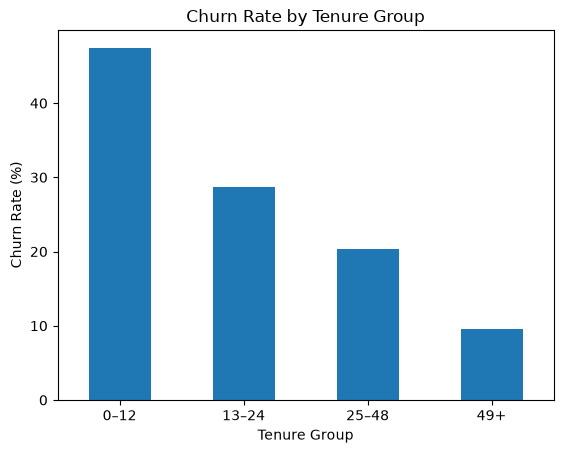

In [26]:
# building the chart
tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Customers with 0–12 months of tenure have the highest churn rate at 47.44%, while churn steadily decreases across the longer-tenure groups, reaching 9.51% among customers with 49+ months. This indicates that newer customers are considerably more likely to churn than long-term customers.

### Monthly Charges: Churned vs Retained

In [27]:
# grouping by churn
monthly_charges_by_churn = df.groupby("Churn")["MonthlyCharges"].mean()
monthly_charges_by_churn

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [28]:
# calculating churn for each category
churned_avg = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].mean()
retained_avg = df.loc[df["Churn"] == "No", "MonthlyCharges"].mean()
print(f"Churned: ${churned_avg:.2f}")
print(f"Retained: ${retained_avg:.2f}")

Churned: $74.44
Retained: $61.27


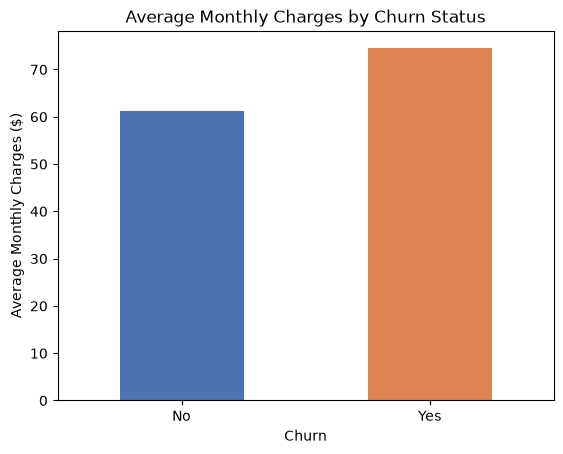

In [29]:
# building the chart
monthly_charges_by_churn.plot(kind="bar", color=['#4C72B0', '#DD8452'])
plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges ($)")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Churned customers have an average monthly charge of $74.44, compared with $61.27 among retained customers. Churned customers therefore pay approximately $13.17 more per month on average, suggesting that higher monthly charges may be associated with greater churn.

### Churn by Payment Method

In [30]:
# checking the categories
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [31]:
# calculating churn
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)
payment_churn

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64

In [32]:
# payment method with highest churn rate
print(f"Payment Method with Highest Churn Rate: {payment_churn.idxmax()}")
print(f"Churn Rate: {payment_churn.max()}")

Payment Method with Highest Churn Rate: Electronic check
Churn Rate: 45.28541226215645


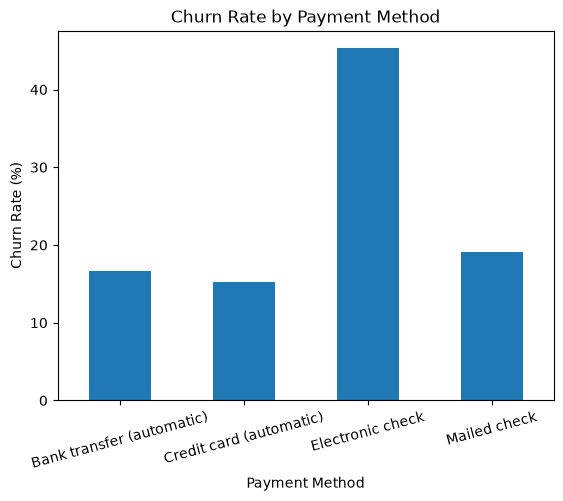

In [33]:
# building the chart
payment_churn.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

**Interpretation:** Customers using electronic checks have the highest churn rate at 45.29%, substantially higher than customers using bank transfer, credit card, or mailed check. The three other payment methods have churn rates between 15.24% and 19.11%, indicating that electronic-check customers represent a particularly high-churn group.

### Churn by Services: Tech Support & Online Security

In [34]:
# checking value counts for each service-related column
service_cols = ["InternetService", "TechSupport", "OnlineSecurity", "DeviceProtection"]
for col in service_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

TechSupport
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


#### Tech Support

In [35]:
# calculating churn rate by tech support status
tech_support_churn = df.groupby("TechSupport")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)
tech_support_churn

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn, dtype: float64

In [36]:
# tech support category with the highest churn rate
print(f"Tech Support category with Highest Churn Rate: {tech_support_churn.idxmax()}")
print(f"Churn Rate: {tech_support_churn.max():.2f}")

Tech Support category with Highest Churn Rate: No
Churn Rate: 41.64


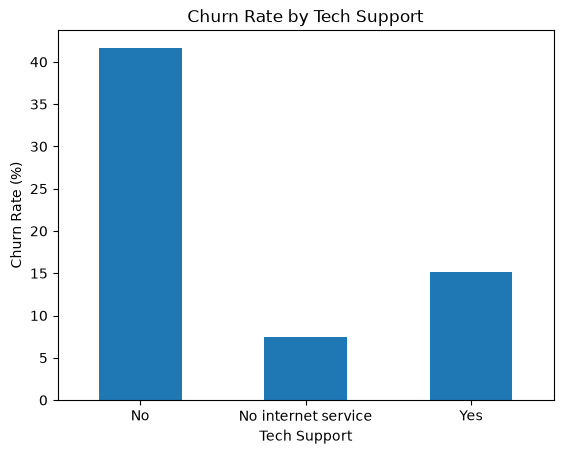

In [37]:
# building the chart
tech_support_churn.plot(kind="bar")
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Customers without Tech Support have the highest churn rate at 41.64%, compared with 15.17% among customers who have Tech Support. Customers with no internet service have a much lower churn rate of 7.40%, indicating a substantial difference in churn across Tech Support categories.

#### Online Security

In [38]:
# calculating churn rate by online security status
online_security_churn = df.groupby("OnlineSecurity")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)
online_security_churn

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64

In [39]:
# online security category with the highest churn rate
print(f"Online Security category with Highest Churn Rate: {online_security_churn.idxmax()}")
print(f"Churn Rate: {online_security_churn.max():.2f}")

Online Security category with Highest Churn Rate: No
Churn Rate: 41.77


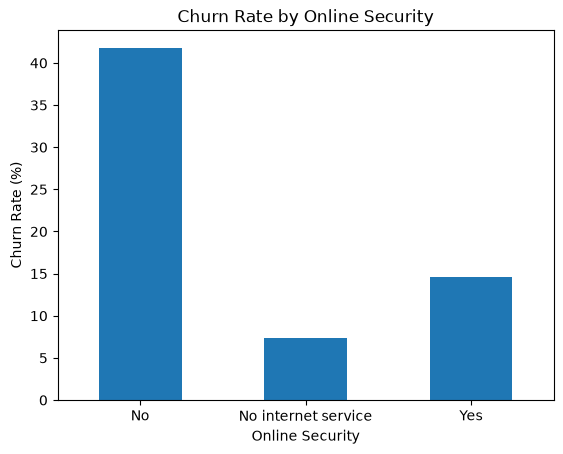

In [40]:
# building the chart
online_security_churn.plot(kind="bar")
plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Customers without Online Security have the highest churn rate at 41.77%, compared with 14.61% among customers who have the service. Customers with no internet service have a churn rate of 7.40%, showing substantially higher churn among customers without Online Security.

## Statistical Analysis (α = 0.05) 

### Test 1 — Contract vs Churn (Chi-Square Test of Independence)

**H₀:** Contract type and churn are independent.\
**H₁:** Contract type and churn are associated.

In [41]:
from scipy.stats import chi2_contingency

# building a contingency table of contract vs churn
contract_churn_table = pd.crosstab(df["Contract"], df["Churn"])
contract_churn_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [42]:
# # running the chi-square test of independence
chi2, p, dof, expected = chi2_contingency(contract_churn_table)

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Degrees of freedom: 2


**Chi-square statistic:** 1184.60\
**p-value:** 5.86 × 10⁻²⁵⁸\
**Decision:** Reject H₀ because p < 0.05.\
**Interpretation:** There is a statistically significant association between contract type and churn. This indicates that churn varies significantly across contract types.

### Test 2 — Monthly Charges vs Churn (Independent Samples T-Test)

**H₀:** The average monthly charges of churned and retained customers are equal.\
**H₁:** The average monthly charges of churned and retained customers are different.

In [43]:
# running the independent samples t-test on monthly charges by churn status
from scipy.stats import ttest_ind

churned_charges = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
retained_charges = df.loc[df["Churn"] == "No", "MonthlyCharges"]
t_stat, p_value = ttest_ind(churned_charges, retained_charges)

In [44]:
# t-test results
print(f"Churned average: {churned_charges.mean()}")
print(f"Retained average: {retained_charges.mean()}")
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

Churned average: 74.44133226324237
Retained average: 61.26512369540008
t-statistic: 16.536738015936308
p-value: 2.706645606888385e-60


**Churned average:** $74.44\
**Retained average:** $61.27\
**t-statistic:** 16.54\
**p-value:** 2.71 × 10⁻⁶⁰\
**Decision:** Reject H₀ because p < 0.05.\
**Interpretation:** There is a statistically significant difference in average monthly charges between churned and retained customers. Churned customers have higher average monthly charges ($74.44) than retained customers ($61.27).

## Customer Segmentation & Revenue at Risk

Customers were divided into four rule-based segments using tenure and monthly charges:
- **New**: tenure ≤ 12 months
- **High-Risk**: tenure > 12 months and monthly charges ≥ $70
- **High-Value**: tenure > 12 months, monthly charges < $70, and tenure ≤ 48 months
- **Loyal**: tenure > 48 months and monthly charges < $70

In [45]:
# defining segment rules based on tenure and monthly charges
def assign_segment(row):
    if row['tenure'] <= 12:
        return 'New'
    elif row['MonthlyCharges'] >= 70:
        return 'High-Risk'
    elif row['tenure'] > 48:
        return 'Loyal'
    else:
        return 'High-Value'
df['Segment'] = df.apply(assign_segment, axis=1)

In [46]:
# summarizing customer count, average tenure, average monthly charges, and churn rate by segment
segment_summary = df.groupby('Segment').agg(
    Customers=('Segment', 'size'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Churn_Rate_Pct=('Churn', lambda x: (x == 'Yes').mean() * 100)
).round(2).sort_values('Churn_Rate_Pct', ascending=False)
segment_summary

,Customers,Avg_Tenure,Avg_Monthly_Charges,Churn_Rate_Pct
Segment,,,,
New,2186,4.73,56.10,47.44
High-Risk,2711,47.04,92.52,24.90
High-Value,1298,28.70,38.48,10.02
Loyal,848,62.35,38.58,3.18


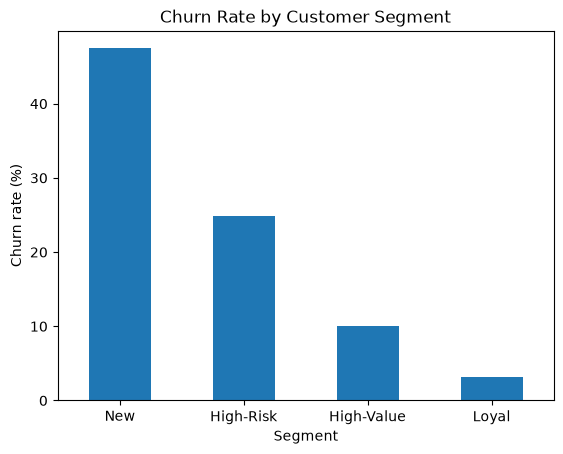

In [47]:
# building the chart
segment_summary['Churn_Rate_Pct'].plot(kind='bar')
plt.title('Churn Rate by Customer Segment')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The New segment requires the most retention attention, with a churn rate of 47.44%, meaning nearly half of customers in this segment have churned. This is substantially higher than the High-Risk segment (24.90%), High-Value segment (10.02%), and Loyal segment (3.18%), making new customers the highest-priority group for retention efforts.

In [48]:
# calculating total monthly revenue at risk from churned customers
revenue_at_risk = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].sum()
print(f"Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")

Monthly Revenue at Risk: $139,130.85


**Interpretation:** This is the total monthly recurring revenue currently lost due to churned customers, that could be protected if these customers were retained.